# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mirl0w/Machine-Learning-Intern/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape)

(30000, 45)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

test_df = df.iloc[test_idx].copy()
test_df["baseline_score"] = (
    ((test_df["days_since_last_update"] >= 180) & (test_df["impressions_90d"] >= 500)).astype(int) * test_df["impressions_90d"] * 0.5
    + ((test_df["ctr"] < 0.3) & (test_df["impressions_90d"] >= 500)).astype(int) * test_df["impressions_90d"] * 0.5
)

tree = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
tree.fit(X_train, y_train)
tree_scores = tree.predict_proba(X_test)[:,1]

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
rf_scores = rf.predict_proba(X_test)[:,1]

results_table = pd.DataFrame({
    "method": ["Baseline (hand rule)", "Decision Tree", "Random Forest"],
    "Precision@20": [
        precision_at_k(test_df["baseline_score"], y_test.values, 20),
        precision_at_k(tree_scores, y_test.values, 20),
        precision_at_k(rf_scores, y_test.values, 20)],
    "Precision@50": [
        precision_at_k(test_df["baseline_score"], y_test.values, 50),
        precision_at_k(tree_scores, y_test.values, 50),
        precision_at_k(rf_scores, y_test.values, 50)],
})
print(results_table)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X, y, test_size=0.2, random_state=42)
tree_n = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
tree_n.fit(X_train_n, y_train_n)
naive_p50 = precision_at_k(tree_n.predict_proba(X_test_n)[:,1], y_test_n.values, 50)
grouped_p50 = precision_at_k(tree_scores, y_test.values, 50)
print(f"\nNaive split Precision@50: {naive_p50:.3f}")
print(f"Client-holdout Precision@50: {grouped_p50:.3f}")

                 method  Precision@20  Precision@50
0  Baseline (hand rule)          0.45          0.44
1         Decision Tree          0.55          0.60
2         Random Forest          0.80          0.72

Naive split Precision@50: 0.660
Client-holdout Precision@50: 0.600


## 1. Question

*The research question and the decision it supports.*

Question: Which content pages should be prioritized for review, given limited
manual-review capacity?

Decision: which pages a content team reviews first, out of thousands, each cycle.
Action: a reviewer manually assesses flagged pages and decides whether to
refresh, rewrite metadata, or leave as-is.
Cost of a wrong call: missing a genuinely declining page (false negative) is
costlier than flagging a healthy page (false positive) — the former means
silent, unnoticed traffic loss; the latter just wastes some review time.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
print(f"Dataset: FlyRank content_refresh_anonymized.csv (starter slice)")
print(f"Rows: {len(df)}, Columns: {df.shape[1]}")
print(f"Declining rate: {df['is_declining_label'].mean():.1%}")

Dataset: FlyRank content_refresh_anonymized.csv (starter slice)
Rows: 30000, Columns: 45
Declining rate: 54.2%


Release used: the starter dataset (data/raw/content_refresh_anonymized.csv),
a 30,000-row anonymized slice covering pages with impressions_90d > 0 and
content_age_days >= 90. The full warehouse release (FlyRank/internship-warehouse,
79M rows) was explored during the Week-3 data contract exercise for schema and
availability checks, but final modeling here uses the starter slice.

Excluded, and why: any FlyRank product decision flags (health_score,
priority_score, action_type) — not present in this data, and deliberately not
reconstructed, since feeding a rebuilt product decision back in as a feature
would be circular (the model would just learn to copy an existing rule).

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label: is_declining_label = (trend_direction == "down"). This is a snapshot-based
proxy label, not a validated future-window outcome — a known limitation carried
through from Week 1.

Features (all observable at decision time, no leakage): content_age_days,
days_since_last_update, impressions_90d, avg_position, ctr, word_count.

Baseline: a hand-written rule (Week 4) combining staleness (days_since_last_update
>= 180), visibility (impressions_90d >= 500), and weak CTR (ctr < 0.3) into a
weighted score.

Model: Decision Tree (max_depth=4), compared against Random Forest (200 trees),
both class-weighted to handle label imbalance.

Validation design: client-holdout (grouped) split — pages belonging to the same
client never appear in both train and test, so the model is judged on clients
it has genuinely never seen. This was directly compared against a naive random
split to show why the grouped design matters (see Results/Limitations).

Leakage checks: confirmed all features were knowable before any outcome was
observed; demonstrated the leakage trap directly in earlier notebooks by
deliberately including trend_pct (a label-derived field) and watching precision
jump artificially — then removed it and kept only the honest feature set.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Under client-holdout validation, the Random Forest reached Precision@50 = 0.72
and Precision@20 = 0.80, compared to the baseline hand-rule's 0.44 and 0.45
respectively — roughly a 1.6x improvement at K=50, and nearly 1.8x at K=20.
The Decision Tree also beat the baseline (0.60 vs 0.44 at K=50) but by a
smaller margin than the Random Forest.

Observed pattern: the Random Forest's advantage is largest at K=20 (0.80 vs
0.45, nearly 2x), suggesting the model is especially strong at identifying
the very highest-priority pages — exactly where a limited-capacity review
team would look first.

## 5. Limitations

*What this work cannot claim.*

This work cannot claim: that a refresh CAUSES recovery (no causal experiment
was run, only observational patterns); that any signal here reflects Google's
actual ranking algorithm; that results generalize beyond this 30,000-row
starter slice or beyond the specific clients represented in it.

Validation design measurably changed the result: under a naive random split,
the decision tree reached Precision@50 = 0.660, but under an honest
client-holdout split — where pages from the same client never appear in both
train and test — Precision@50 dropped to 0.600. This gap shows the naive
split was somewhat optimistic: the model was likely picking up some
client-specific patterns that don't transfer to genuinely unseen clients.
The client-holdout number (0.600) is the one that should be trusted as a
realistic estimate of real-world performance.

The label itself (trend_direction == "down") is also a snapshot proxy, not a
true future-window outcome — a stronger next iteration would define decline
as "did this page's performance drop over the NEXT 30 days," which this
version does not yet do.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The action playbook maps model output into four categories:
- refresh_content: stale AND still visible pages — highest priority
- rewrite_title_meta: visible pages with strong position but weak CTR
- review_priority: elevated model risk without a clear single cause
- monitor: low priority, no action needed now

Every "refresh_content" and "rewrite_title_meta" flag requires human review
before any live change — the model surfaces candidates, it does not approve
edits.

No-go cases (never automated): auto-publishing edits from model score alone;
auto-deleting or de-indexing pages without sign-off; treating a high score as
proof a refresh WILL cause recovery (a causal claim this data cannot support).

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

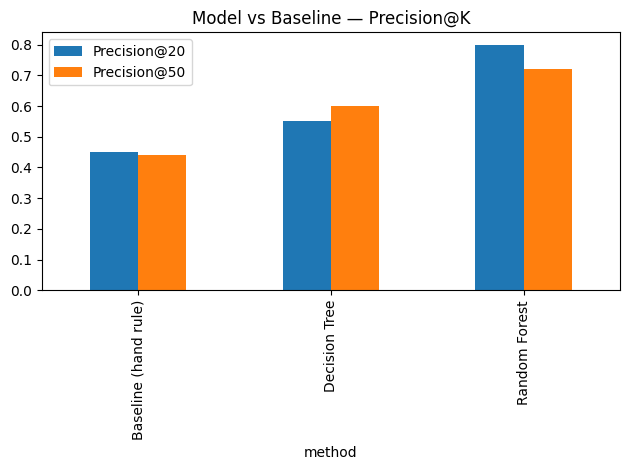

Saved figure to work/figures/, metrics to work/outputs/


In [ ]:
os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

import matplotlib.pyplot as plt
results_table.set_index("method")[["Precision@20","Precision@50"]].plot(
    kind="bar", title="Model vs Baseline — Precision@K")
plt.tight_layout()
plt.savefig("work/figures/results_comparison.png")
plt.show()

import json
summary_metrics = {
    "results_table": results_table.to_dict(orient="records"),
    "naive_split_precision_50": float(naive_p50),
    "grouped_split_precision_50": float(grouped_p50),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(summary_metrics, f, indent=2)
print("Saved figure to work/figures/, metrics to work/outputs/")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


### 5-minute demo outline

1. The problem: too many pages, too little review capacity (30 sec)
2. The baseline hand-rule, and its limits (1 min)
3. The model — shown as a readable decision tree, same interpretability as
   the baseline (1.5 min)
4. Results: model vs baseline under honest client-holdout validation —
   Precision@50 of 0.72 vs 0.44 (1 min)
5. The action playbook: ranked queue + mandatory human review (1 min)

### Social-post cut

Built an ML pipeline that ranks web pages by decline risk for prioritized
content review. Compared a hand-written baseline rule against a Random Forest
classifier under strict client-holdout validation (never testing on clients
seen during training) — the model reached 0.72 Precision@50 vs the baseline's
0.44, a 1.6x improvement. Full writeup + reproducible code:
https://mirl0w.github.io/Machine-Learning-Intern/

### 3-sentence employer-facing summary

Built an end-to-end machine learning pipeline for content prioritization,
training and validating a Decision Tree and Random Forest classifier against
a hand-written baseline rule, with formal leakage audits and client-holdout
validation to prevent overfitting. The Random Forest achieved a 1.6x
improvement in Precision@50 over the baseline (0.72 vs 0.44), and model
output was translated into a human-reviewable action playbook with defined
no-go cases and monitoring triggers. Full work — including the data contract,
signal audits, and reproducible notebooks — is public on GitHub:
https://github.com/mirl0w/Machine-Learning-Intern